In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_users = pd.read_csv("acc-data/ACC-usagers-2018.csv")
df_users

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh
0,201800000001,1.0,1,3,1,0.0,11.0,0.0,0.0,0.0,1928.0,B01
1,201800000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,1960.0,A01
2,201800000002,1.0,1,1,1,0.0,11.0,0.0,0.0,0.0,1947.0,A01
3,201800000002,NaN,3,4,1,0.0,2.0,2.0,3.0,1.0,1959.0,A01
4,201800000003,1.0,1,3,1,5.0,21.0,0.0,0.0,0.0,1987.0,A01
...,...,...,...,...,...,...,...,...,...,...,...,...
130164,201800057781,NaN,3,4,1,9.0,3.0,4.0,3.0,1.0,1975.0,A01
130165,201800057782,1.0,1,4,2,9.0,11.0,NaN,NaN,NaN,1993.0,A01
130166,201800057782,1.0,1,4,1,9.0,21.0,NaN,NaN,NaN,1974.0,B01
130167,201800057783,1.0,1,4,1,9.0,11.0,NaN,NaN,NaN,1973.0,B01


In [3]:
df1 = df_users[["Num_Acc","grav","an_nais","catu"]]
df1 = df1.where(df1['catu'] == 1 )
df1 = df1.dropna()
df1.reset_index()
df1

,Num_Acc,grav,an_nais,catu
0,2.018000e+11,3.0,1928.0,1.0
1,2.018000e+11,1.0,1960.0,1.0
2,2.018000e+11,1.0,1947.0,1.0
4,2.018000e+11,3.0,1987.0,1.0
5,2.018000e+11,1.0,1977.0,1.0
...,...,...,...,...
130163,2.018001e+11,1.0,1989.0,1.0
130165,2.018001e+11,4.0,1993.0,1.0
130166,2.018001e+11,4.0,1974.0,1.0
130167,2.018001e+11,4.0,1973.0,1.0


In [4]:
results = df1.groupby("an_nais")["Num_Acc"].size()
results = results.reset_index()
results

,an_nais,Num_Acc
0,1917.0,1
1,1918.0,2
2,1919.0,1
3,1920.0,1
4,1921.0,4
...,...,...
94,2011.0,16
95,2012.0,10
96,2013.0,2
97,2014.0,9


In [5]:
"""n = len(results)

in_per = lambda x : x/n
results['Num_Acc'] = results['Num_Acc'].map(in_per)

results"""

"n = len(results)\n\nin_per = lambda x : x/n\nresults['Num_Acc'] = results['Num_Acc'].map(in_per)\n\nresults"

In [6]:
df1
results2 = df1.groupby(["grav",'an_nais'])["Num_Acc"].size()
results2 = results2.reset_index()
results2

,grav,an_nais,Num_Acc
0,1.0,1918.0,1
1,1.0,1919.0,1
2,1.0,1920.0,1
3,1.0,1921.0,2
4,1.0,1922.0,3
...,...,...,...
360,4.0,2010.0,10
361,4.0,2011.0,9
362,4.0,2012.0,6
363,4.0,2014.0,6


NameError: name 'bins' is not defined

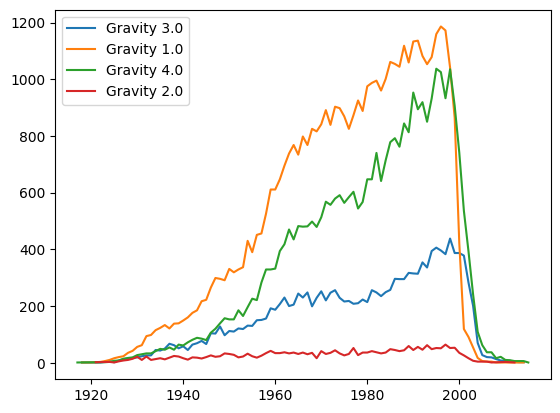

In [7]:
for grav_level in df1['grav'].unique():
    subset = results2[results2['grav'] == grav_level]
    subset = pd.DataFrame(subset)
    subset = subset.sort_values('an_nais')
    plt.plot(subset.an_nais,subset.Num_Acc,label = f"Gravity {grav_level}")

plt.legend()
plt.xticks(bins.round())



In [ ]:
results['Num_Acc'].max()

np.int64(2658)


(array([  11.2,  150.3,  336.1,  663.9, 1133.6, 1641.1, 1865. , 2353.2,
       1421.1,   24.3]), array([1917. , 1926.8, 1936.6, 1946.4, 1956.2, 1966. , 1975.8, 1985.6,
       1995.4, 2005.2, 2015. ]), <BarContainer object of 10 artists>)


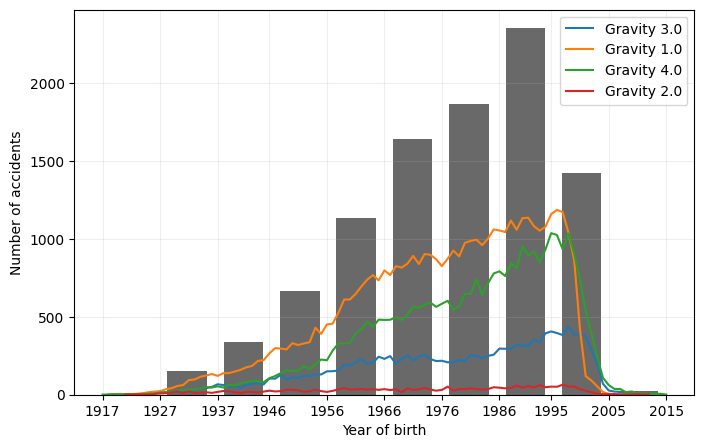

In [ ]:
bins = np.linspace(1917,2015,11)

#plt.bar(x=results.an_nais,height=results.Num_Acc)
fig , ax = plt.subplots(figsize=(8,5))
counts = ax.hist(results["an_nais"], bins=bins, weights=results["Num_Acc"]/10,color='dimgray',rwidth=0.7)
ax.grid(True,alpha=0.2)
ax.set_xticks(bins.round())
ax.set_xlabel("Year of birth")
ax.set_ylabel("Number of accidents")

for grav_level in df1['grav'].unique():
    subset = results2[results2['grav'] == grav_level]
    subset = pd.DataFrame(subset)
    subset = subset.sort_values('an_nais')
    plt.plot(subset.an_nais,subset.Num_Acc,label = f"Gravity {grav_level}")

plt.legend()
print()
print(counts)



Text(0.5, 0, 'Year of birth')

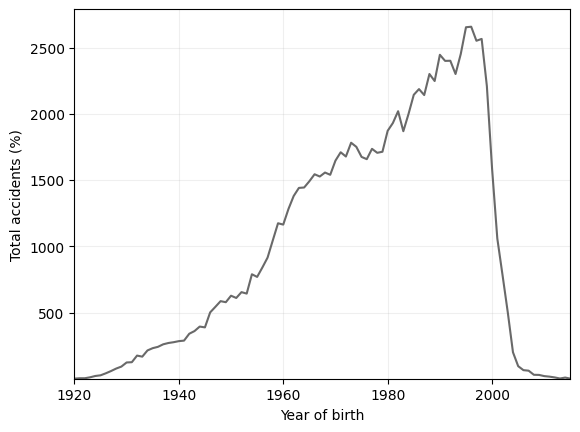

In [ ]:
fig , ax = plt.subplots()
ax.plot(results["an_nais"],results["Num_Acc"],'dimgray')
ax.grid(True,alpha=0.2)
ax.set_ylim(ymin=0.3)
ax.set_xlim(xmin=1920,xmax=2015)
ax.set_ylabel("Total accidents (%)")
ax.set_xlabel("Year of birth")


# For paris / lyon

In [ ]:
df_acc = pd.read_csv('acc-data/ACC-caracteristiques-2018.csv')


In [ ]:
merged = df_acc.merge(df_users,how="inner",on='Num_Acc')
merged

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh
0,201800000001,18,1,24,1505,1,1,4,1.0,1.0,...,1,3,1,0.0,11.0,0.0,0.0,0.0,1928.0,B01
1,201800000001,18,1,24,1505,1,1,4,1.0,1.0,...,1,1,1,5.0,11.0,0.0,0.0,0.0,1960.0,A01
2,201800000002,18,2,12,1015,1,2,7,7.0,7.0,...,1,1,1,0.0,11.0,0.0,0.0,0.0,1947.0,A01
3,201800000002,18,2,12,1015,1,2,7,7.0,7.0,...,3,4,1,0.0,2.0,2.0,3.0,1.0,1959.0,A01
4,201800000003,18,3,4,1135,1,2,3,1.0,7.0,...,1,3,1,5.0,21.0,0.0,0.0,0.0,1987.0,A01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130164,201800057781,18,12,22,2150,5,2,1,1.0,6.0,...,3,4,1,9.0,3.0,4.0,3.0,1.0,1975.0,A01
130165,201800057782,18,12,23,1945,5,2,1,1.0,1.0,...,1,4,2,9.0,11.0,NaN,NaN,NaN,1993.0,A01
130166,201800057782,18,12,23,1945,5,2,1,1.0,1.0,...,1,4,1,9.0,21.0,NaN,NaN,NaN,1974.0,B01
130167,201800057783,18,12,28,1425,1,2,1,1.0,1.0,...,1,4,1,9.0,11.0,NaN,NaN,NaN,1973.0,B01


In [ ]:
merged = merged[["Num_Acc","grav","an_nais","catu","dep"]]
merged

,Num_Acc,grav,an_nais,catu,dep
0,201800000001,3,1928.0,1,590
1,201800000001,1,1960.0,1,590
2,201800000002,1,1947.0,1,590
3,201800000002,4,1959.0,3,590
4,201800000003,3,1987.0,1,590
...,...,...,...,...,...
130164,201800057781,4,1975.0,3,976
130165,201800057782,4,1993.0,1,976
130166,201800057782,4,1974.0,1,976
130167,201800057783,4,1973.0,1,976


In [ ]:
lyon = merged.where(merged["dep"] == 690)
lyon = lyon.dropna()
lyon

,Num_Acc,grav,an_nais,catu,dep
3693,2.018000e+11,1.0,1950.0,1.0,690.0
3694,2.018000e+11,3.0,1931.0,3.0,690.0
3695,2.018000e+11,4.0,2000.0,1.0,690.0
3696,2.018000e+11,3.0,2001.0,2.0,690.0
3697,2.018000e+11,1.0,1953.0,1.0,690.0
...,...,...,...,...,...
112199,2.018000e+11,2.0,1960.0,1.0,690.0
112200,2.018000e+11,1.0,1942.0,2.0,690.0
112201,2.018000e+11,4.0,2008.0,2.0,690.0
112202,2.018000e+11,1.0,1961.0,2.0,690.0


In [ ]:
paris = merged.where(merged["dep"] == 750)
paris = paris.dropna()
paris

,Num_Acc,grav,an_nais,catu,dep
98305,2.018000e+11,4.0,1972.0,1.0,750.0
98306,2.018000e+11,1.0,1991.0,1.0,750.0
98434,2.018000e+11,1.0,1957.0,1.0,750.0
98435,2.018000e+11,4.0,2011.0,2.0,750.0
98436,2.018000e+11,1.0,1969.0,1.0,750.0
...,...,...,...,...,...
125466,2.018001e+11,1.0,1988.0,1.0,750.0
125467,2.018001e+11,4.0,1989.0,1.0,750.0
125468,2.018001e+11,1.0,1998.0,1.0,750.0
125469,2.018001e+11,1.0,1992.0,1.0,750.0


In [ ]:
lyon = lyon[lyon["catu"] == 1.0]
paris = paris[paris["catu"] == 1.0]

In [ ]:
lyon_hist = lyon.groupby('an_nais')["Num_Acc"].size()
lyon_hist = lyon_hist.reset_index()

paris_hist = paris.groupby('an_nais')['Num_Acc'].size()
paris_hist = paris_hist.reset_index()


,an_nais,Num_Acc
0,1924.0,1
1,1925.0,3
2,1926.0,1
3,1927.0,3
4,1928.0,3
...,...,...
80,2004.0,8
81,2005.0,2
82,2006.0,4
83,2007.0,4


In [ ]:
lyon_plots = lyon.groupby(["grav","an_nais"])["Num_Acc"].size()
lyon_plots = lyon_plots.reset_index()

paris_plots = paris.groupby(["grav","an_nais"])["Num_Acc"].size()
paris_plots = paris_plots.reset_index()

,grav,an_nais,Num_Acc
0,1.0,1922.0,1
1,1.0,1923.0,1
2,1.0,1924.0,1
3,1.0,1928.0,3
4,1.0,1929.0,5
...,...,...,...
245,4.0,2008.0,1
246,4.0,2009.0,1
247,4.0,2010.0,3
248,4.0,2011.0,1


Time to plot

In [ ]:
grav_labels = {
    1: "Fine",
    2: "Killed",
    3: "Hospitalised",
    4: "Slightly hurt"
}

colors = {
    1 : 'tab:green',
    2 : 'firebrick',
    3 : 'gold',
    4 : 'tab:blue'
}

NameError: name 'tmp' is not defined

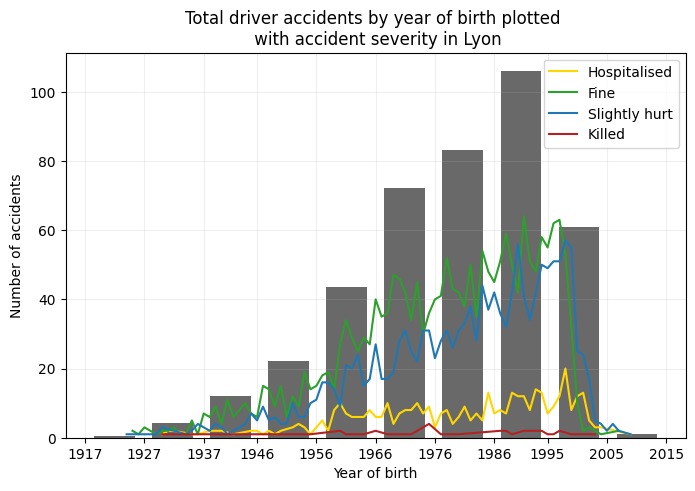

In [ ]:
bins = np.linspace(1917,2015,11)

fig , ax = plt.subplots(figsize=(8,5))
counts = ax.hist(lyon_hist["an_nais"], bins=bins, weights=lyon_hist["Num_Acc"]/10,color='dimgray',rwidth=0.7)
ax.grid(True,alpha=0.2)
ax.set_xticks(bins.round())
ax.set_xlabel("Year of birth")
ax.set_ylabel("Number of accidents")

for grav_level in df1['grav'].unique():
    subset = lyon_plots[lyon_plots['grav'] == grav_level]
    subset = pd.DataFrame(subset)
    subset = subset.sort_values('an_nais')
    plt.plot(subset.an_nais,subset.Num_Acc,colors[grav_level],label = grav_labels[grav_level],)

plt.legend()
plt.title("Total driver accidents by year of birth plotted \n with accident severity in Lyon")



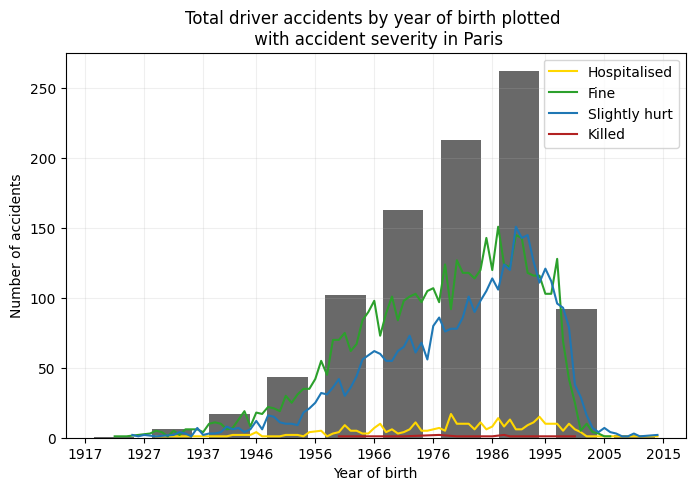

In [ ]:
bins = np.linspace(1917,2015,11)    


fig , ax = plt.subplots(figsize=(8,5))
counts = ax.hist(paris_hist["an_nais"], bins=bins, weights=paris_hist["Num_Acc"]/10,color='dimgray',rwidth=0.7)
ax.grid(True,alpha=0.2)
ax.set_xticks(bins.round())
ax.set_xlabel("Year of birth")
ax.set_ylabel("Number of accidents")

for grav_level in df1['grav'].unique():
    subset = paris_plots[paris_plots['grav'] == grav_level]
    subset = pd.DataFrame(subset)
    subset = subset.sort_values('an_nais')
    plt.plot(subset.an_nais,subset.Num_Acc,colors[grav_level],label = grav_labels[grav_level])

plt.legend()
plt.title("Total driver accidents by year of birth plotted \n with accident severity in Paris")
print()
